In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow_addons as tfa
from tensorflow.keras.utils import image_dataset_from_directory

DATA PREPERATION

In [2]:
training_set = image_dataset_from_directory(
    "./train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 76515 files belonging to 4 classes.


In [39]:
validation_set = image_dataset_from_directory(
    "./val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 21861 files belonging to 4 classes.


In [4]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [5]:
INPUT_SHAPE = (224, 224, 3)

In [6]:
mobnet = tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling=None,
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=True,
    #name="MobileNetV3Large",
)


In [7]:
#If you want perform transfer learning then execute this cell
# mobnet.trainable = False

In [8]:
model = tf.keras.models.Sequential()

In [9]:
model.add(tf.keras.Input(shape=INPUT_SHAPE))

In [10]:
model.add(mobnet)

In [11]:
model.add(tf.keras.layers.Dense(units = 4, activation="softmax"))

In [12]:
metrics_list = ["accuracy", tfa.metrics.F1Score(num_classes=4, average="macro")] 

In [13]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=metrics_list)


In [14]:
#mobile = tf.keras.applications.MobileNetV3Large()

In [15]:
#mobile.summary()

In [16]:
#x = mobile.layers[-4].output
#output = tf.keras.layers.Dense(units = 10 , activation = 'softmax')(x)



In [17]:
#model2 = tf.keras.Model(input=mobile.input, output= output)

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense (Dense)               (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [19]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=15,batch_size=16,verbose=1)

Epoch 1/15
4783/4783 [==============================] - 551s 113ms/step - loss: 1.0101 - accuracy: 0.8748 - f1_score: 0.6620 - val_loss: 0.7730 - val_accuracy: 0.8922 - val_f1_score: 0.6892
Epoch 2/15
4783/4783 [==============================] - 540s 113ms/step - loss: 0.6147 - accuracy: 0.8932 - f1_score: 0.7218 - val_loss: 0.4742 - val_accuracy: 0.9565 - val_f1_score: 0.9237
Epoch 3/15
4783/4783 [==============================] - 541s 113ms/step - loss: 0.4014 - accuracy: 0.9514 - f1_score: 0.9150 - val_loss: 0.3244 - val_accuracy: 0.9602 - val_f1_score: 0.9305
Epoch 4/15
4783/4783 [==============================] - 541s 113ms/step - loss: 0.2781 - accuracy: 0.9584 - f1_score: 0.9281 - val_loss: 0.2316 - val_accuracy: 0.9657 - val_f1_score: 0.9392
Epoch 5/15
4783/4783 [==============================] - 541s 113ms/step - loss: 0.2021 - accuracy: 0.9661 - f1_score: 0.9412 - val_loss: 0.1772 - val_accuracy: 0.9663 - val_f1_score: 0.9428
Epoch 6/15
4783/4783 [============================

In [20]:
model.save("./Trained_Eye_disease_model.h5")
model.save("./Trained_Eye_disease_model_weights.keras")

In [21]:
training_history.history

{'loss': [1.0101104974746704,
  0.614741861820221,
  0.40135207772254944,
  0.2780742645263672,
  0.20208176970481873,
  0.15237712860107422,
  0.12081010639667511,
  0.0957520604133606,
  0.0810282900929451,
  0.06992455571889877,
  0.06408756971359253,
  0.0563683845102787,
  0.049318842589855194,
  0.0480036623775959,
  0.04562150314450264],
 'accuracy': [0.8747827410697937,
  0.8932104706764221,
  0.9513689875602722,
  0.9583872556686401,
  0.9660981297492981,
  0.9716264605522156,
  0.9758740067481995,
  0.98093181848526,
  0.983022928237915,
  0.9858459234237671,
  0.9869829416275024,
  0.9883029460906982,
  0.9900150299072266,
  0.9899235367774963,
  0.9907469153404236],
 'f1_score': [0.6620262861251831,
  0.7218437194824219,
  0.9149941205978394,
  0.9281215071678162,
  0.9412153959274292,
  0.9508492946624756,
  0.9580618143081665,
  0.9669776558876038,
  0.9704408645629883,
  0.9755237102508545,
  0.9774442911148071,
  0.9798288941383362,
  0.9825664758682251,
  0.98263996839

In [22]:
import pickle   
with open('Training_history.pkl', 'wb') as f:
    pickle.dump(training_history.history, f)

In [23]:
import pickle
with open("Training_history.pkl","rb") as f:
    load_history = pickle.load(f)
print(load_history)

{'loss': [1.0101104974746704, 0.614741861820221, 0.40135207772254944, 0.2780742645263672, 0.20208176970481873, 0.15237712860107422, 0.12081010639667511, 0.0957520604133606, 0.0810282900929451, 0.06992455571889877, 0.06408756971359253, 0.0563683845102787, 0.049318842589855194, 0.0480036623775959, 0.04562150314450264], 'accuracy': [0.8747827410697937, 0.8932104706764221, 0.9513689875602722, 0.9583872556686401, 0.9660981297492981, 0.9716264605522156, 0.9758740067481995, 0.98093181848526, 0.983022928237915, 0.9858459234237671, 0.9869829416275024, 0.9883029460906982, 0.9900150299072266, 0.9899235367774963, 0.9907469153404236], 'f1_score': [0.6620262861251831, 0.7218437194824219, 0.9149941205978394, 0.9281215071678162, 0.9412153959274292, 0.9508492946624756, 0.9580618143081665, 0.9669776558876038, 0.9704408645629883, 0.9755237102508545, 0.9774442911148071, 0.9798288941383362, 0.9825664758682251, 0.9826399683952332, 0.9840092658996582], 'val_loss': [0.7730358839035034, 0.4742434620857239, 0.3

In [24]:
load_history.keys()

dict_keys(['loss', 'accuracy', 'f1_score', 'val_loss', 'val_accuracy', 'val_f1_score'])

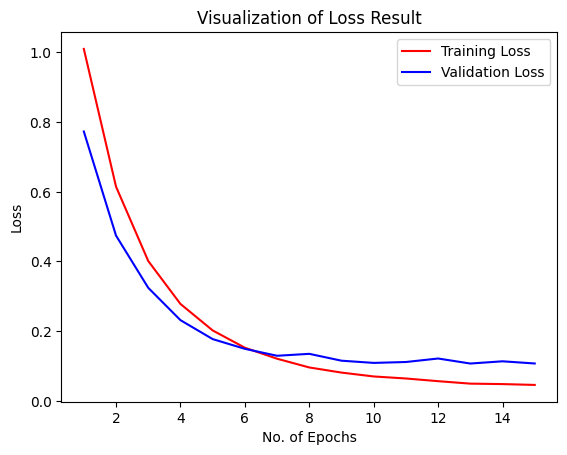

In [25]:
#Loss Visualization
epochs = [i for i in range(1,16)]
plt.plot(epochs,load_history['loss'],color='red',label='Training Loss')
plt.plot(epochs,load_history['val_loss'],color='blue',label='Validation Loss')
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.title("Visualization of Loss Result")
plt.legend()
plt.show()


Model Evaluation

In [26]:
model = tf.keras.models.load_model("Trained_Eye_disease_model.h5")

In [27]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense (Dense)               (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [28]:
test_set = image_dataset_from_directory(
    "./test",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 10933 files belonging to 4 classes.


In [29]:
test_loss,test_acc,f1_score = model.evaluate(test_set)

342/342 [==============================] - 23s 60ms/step - loss: 0.1134 - accuracy: 0.9726 - f1_score: 0.9521


In [30]:
test_loss, test_acc, f1_score

(0.11343343555927277, 0.9725601673126221, 0.9520882368087769)

In [31]:
#Computing True label from test set
true_categories = tf.concat([y for x,y in test_set],axis=0)
Y_true = tf.argmax(true_categories,axis=1)


In [32]:
true_categories

<tf.Tensor: shape=(10933, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], dtype=float32)>

In [33]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [34]:
#Computing Predicting labels using test_set
predicted_categories = model.predict(test_set)
predicted_categories

342/342 [==============================] - 20s 57ms/step


array([[9.9284279e-01, 2.2789172e-03, 3.6658468e-03, 1.2124148e-03],
       [9.9286747e-01, 2.2745770e-03, 3.6490420e-03, 1.2088945e-03],
       [9.9276745e-01, 2.2917443e-03, 3.7178076e-03, 1.2229708e-03],
       ...,
       [5.7091424e-04, 1.8202302e-03, 2.9286996e-03, 9.9468011e-01],
       [5.7091424e-04, 1.8202302e-03, 2.9286996e-03, 9.9468011e-01],
       [5.7091424e-04, 1.8202302e-03, 2.9286996e-03, 9.9468011e-01]],
      dtype=float32)

In [35]:
Y_Pred = tf.argmax(predicted_categories,axis=1)
Y_Pred

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

1. Classification Report

In [36]:
from sklearn.metrics import classification_report
print(classification_report(Y_true, Y_Pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3746
           1       0.98      0.94      0.96      1161
           2       0.88      0.89      0.88       887
           3       0.98      0.99      0.99      5139

    accuracy                           0.97     10933
   macro avg       0.95      0.95      0.95     10933
weighted avg       0.97      0.97      0.97     10933



2. Confusion Matrix

In [37]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_true, Y_Pred)
cm

array([[3657,   12,   72,    5],
       [  19, 1094,    6,   42],
       [  52,    2,  788,   45],
       [   4,   11,   30, 5094]], dtype=int64)

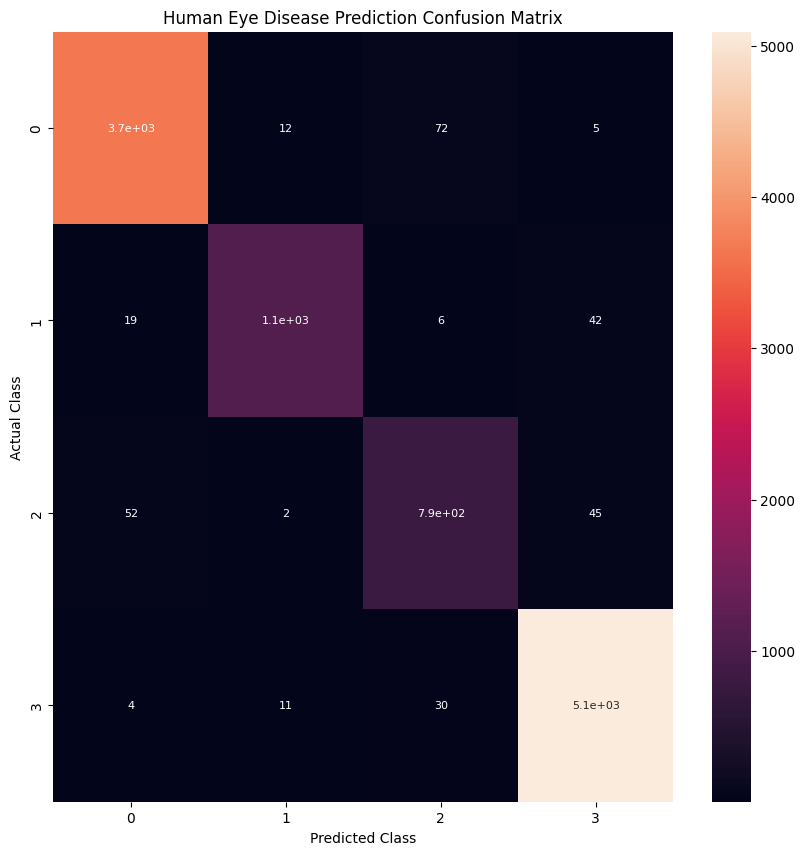

In [38]:
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={"size":8})
plt.xlabel("Predicted Class", fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Human Eye Disease Prediction Confusion Matrix",fontsize=12)
plt.show()